Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets      : 11
   Train/Test    : 70% / 30%
   penalty       : l2
   C             : 1.0
   solver        : lbfgs
   class_weight  : balanced
   max_iter      : 1000
  Logistic Regression — C Sensitivity Analysis

  AAC        → C=0.001:0.564  C=0.01:0.565  C=0.1:0.565  C=1:0.566  C=10:0.566  C=100:0.566
             Best C = 1  (AUC=0.5656)

  DPC        → C=0.001:0.569  C=0.01:0.558  C=0.1:0.546  C=1:0.541  C=10:0.540  C=100:0.540
             Best C = 0.001  (AUC=0.5694)

  CTDC       → C=0.001:0.518  C=0.01:0.525  C=0.1:0.533  C=1:0.535  C=10:0.535  C=100:0.535
             Best C = 100  (AUC=0.5354)

  CTDT       → C=0.001:0.519  C=0.01:0.532  C=0.1:0.536  C=1:0.536  C=10:0.536  C=100:0.536
             Best C = 10  (AUC=0.5363)

  GAAC       → C=0.001:0.513  C=0.01:0.514  C=0.1:0.515  C=1:0.515  C=10:0.515  C=100:0.515
             Best C = 1  (AUC=0.5149)

  PAAC       → C=0.001:0.552  C=0.01:0.561  C=0.1:0.564 

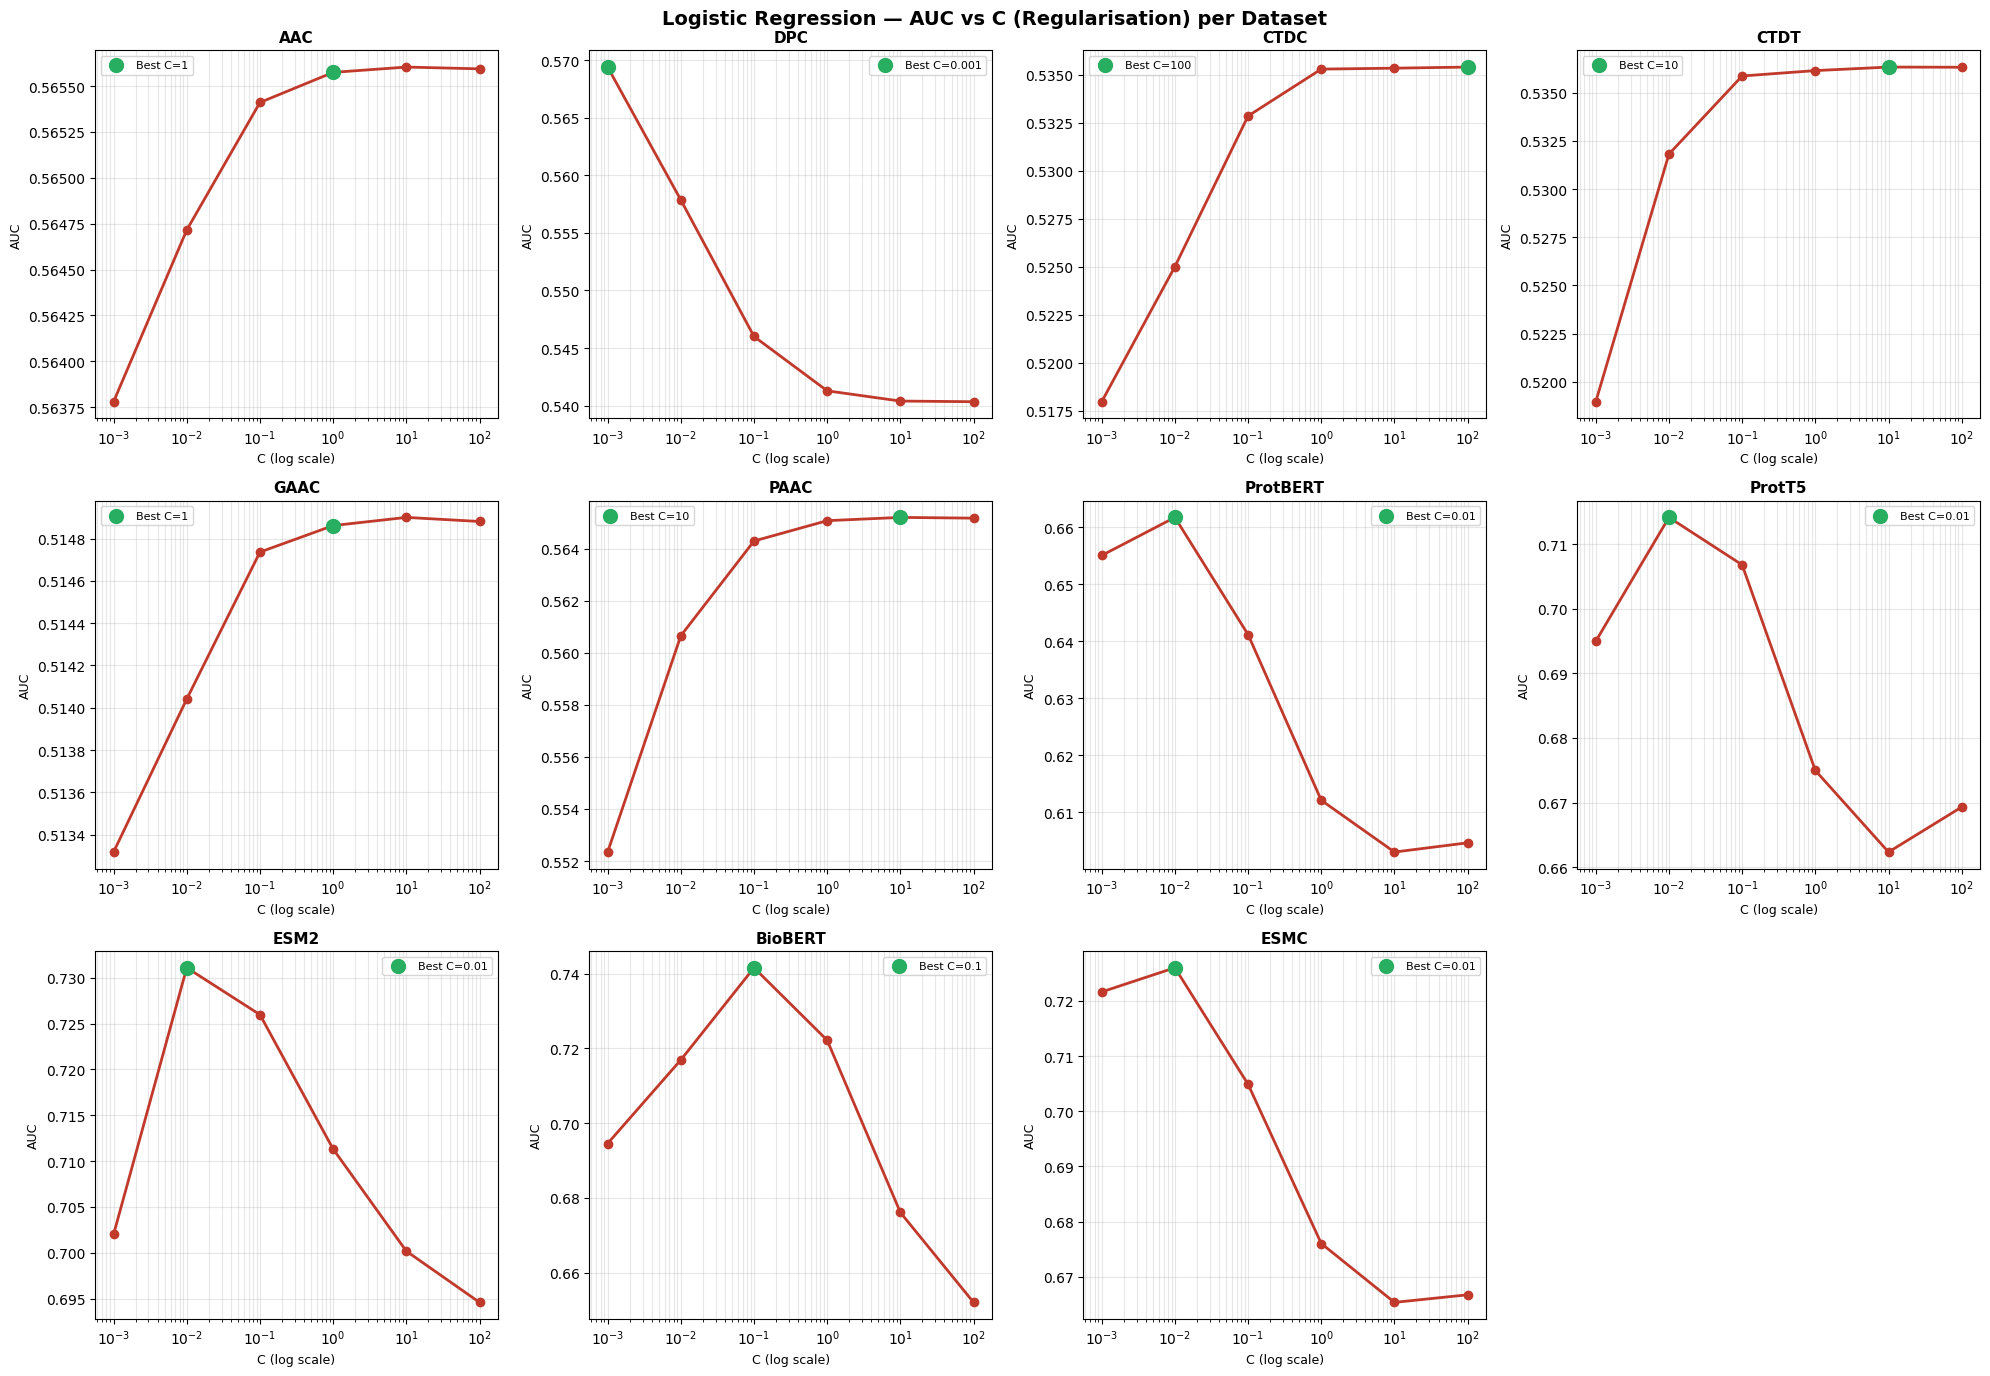

✅ C sensitivity plot saved
  Logistic Regression — Penalty Comparison per Dataset

  AAC        → l1:0.565  l2:0.566  elasticnet:0.565
             Best penalty = l2  (AUC=0.5656)

  DPC        → l1:0.500  l2:0.569  elasticnet:0.500
             Best penalty = l2  (AUC=0.5694)

  CTDC       → l1:0.535  l2:0.535  elasticnet:0.535
             Best penalty = l1  (AUC=0.5354)

  CTDT       → l1:0.536  l2:0.536  elasticnet:0.536
             Best penalty = l1  (AUC=0.5362)

  GAAC       → l1:0.515  l2:0.515  elasticnet:0.514
             Best penalty = l2  (AUC=0.5149)

  PAAC       → l1:0.565  l2:0.565  elasticnet:0.565
             Best penalty = l2  (AUC=0.5651)

  ProtBERT   → l1:0.544  l2:0.661  elasticnet:0.604
             Best penalty = l2  (AUC=0.6615)

  ProtT5     → l1:0.606  l2:0.714  elasticnet:0.656
             Best penalty = l2  (AUC=0.7140)

  ESM2       → l1:0.636  l2:0.731  elasticnet:0.677
             Best penalty = l2  (AUC=0.7311)

  BioBERT    → l1:0.706  l2:0.742  

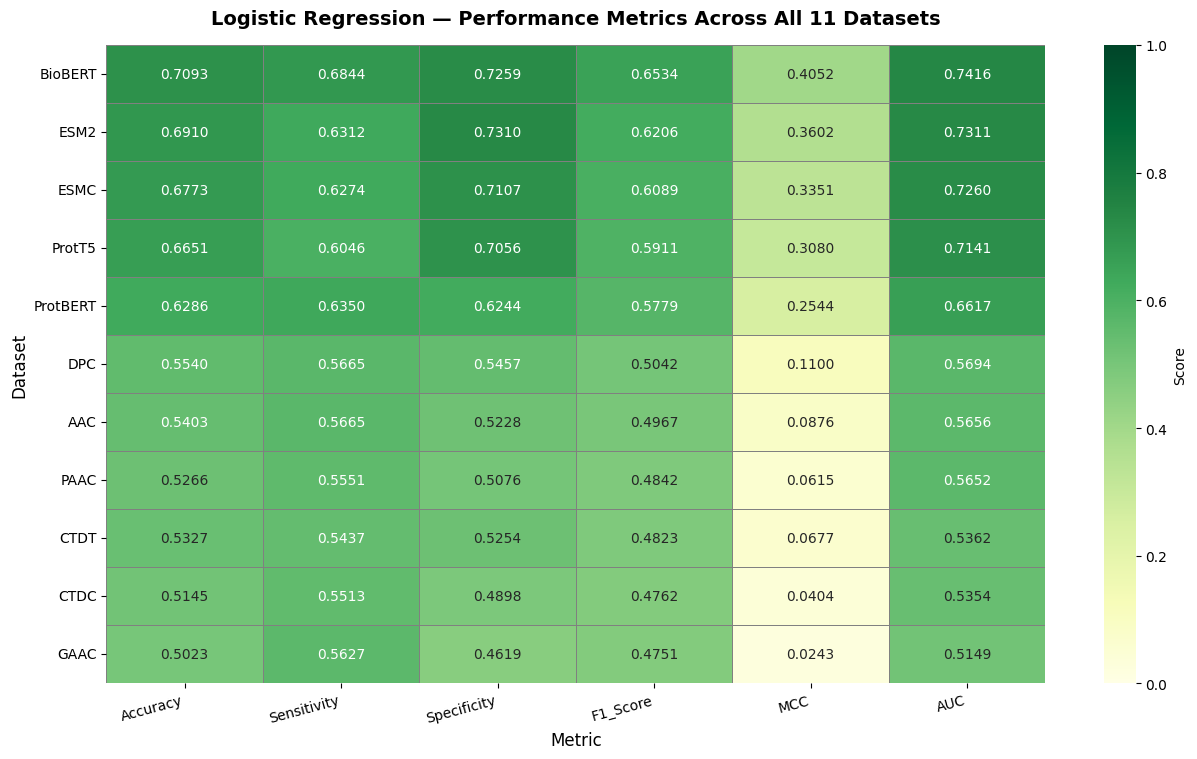

✅ Metrics heatmap saved


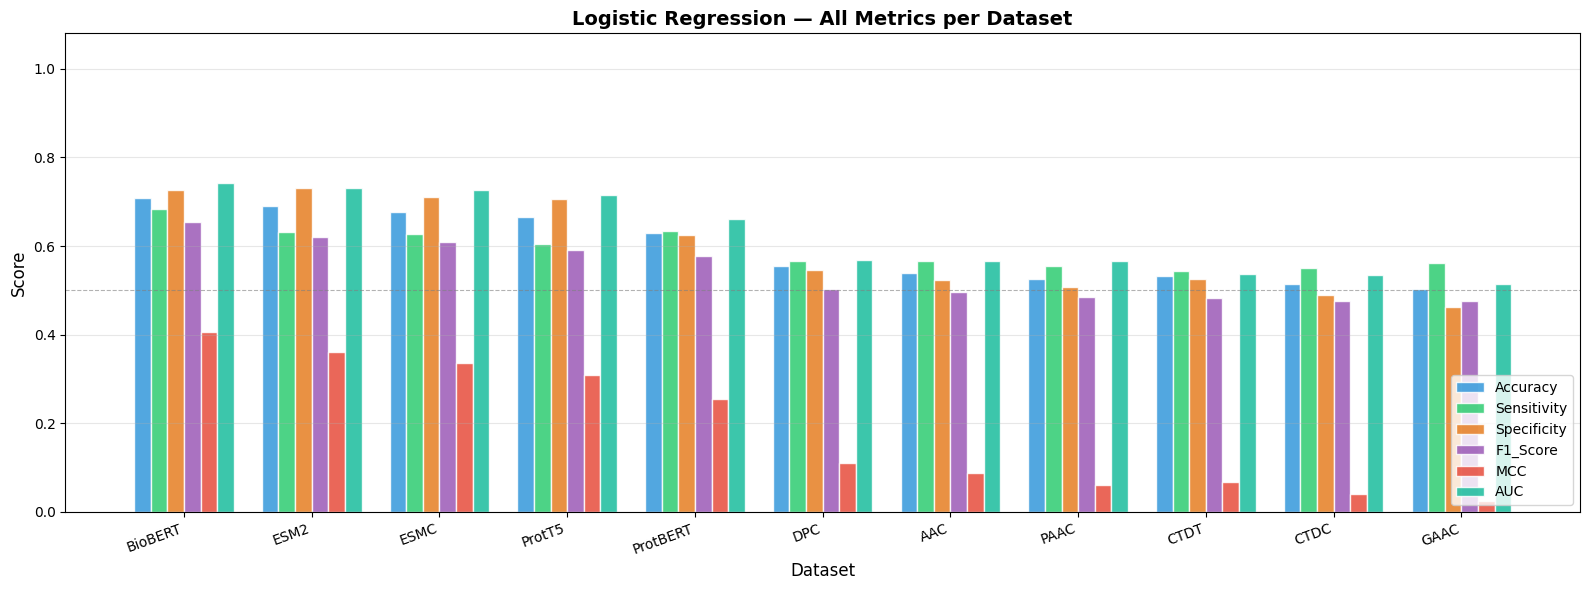

✅ Grouped bar chart saved


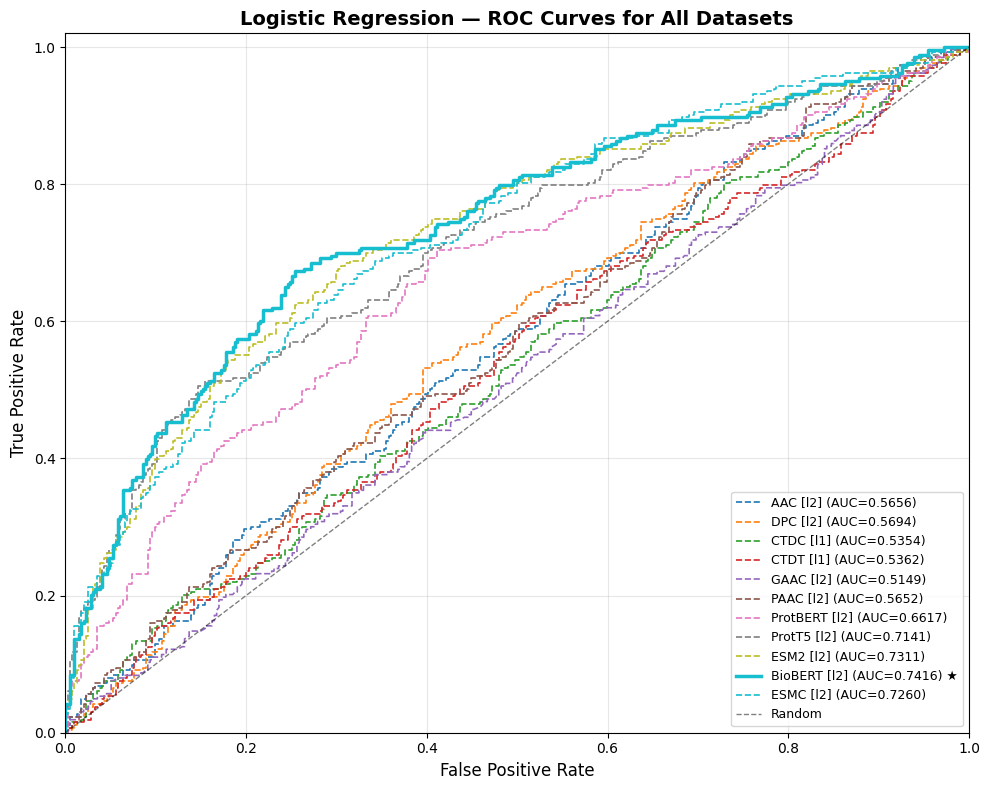

✅ ROC curves saved


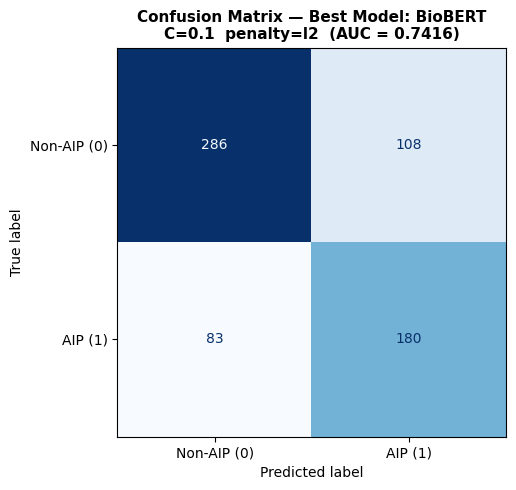

✅ Confusion matrix saved (BioBERT)


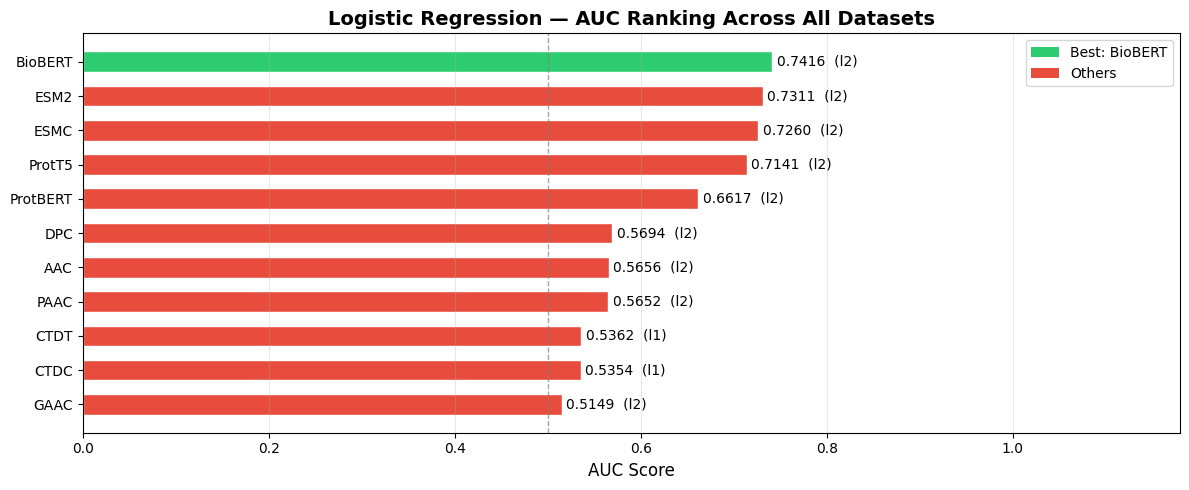

✅ AUC ranking chart saved


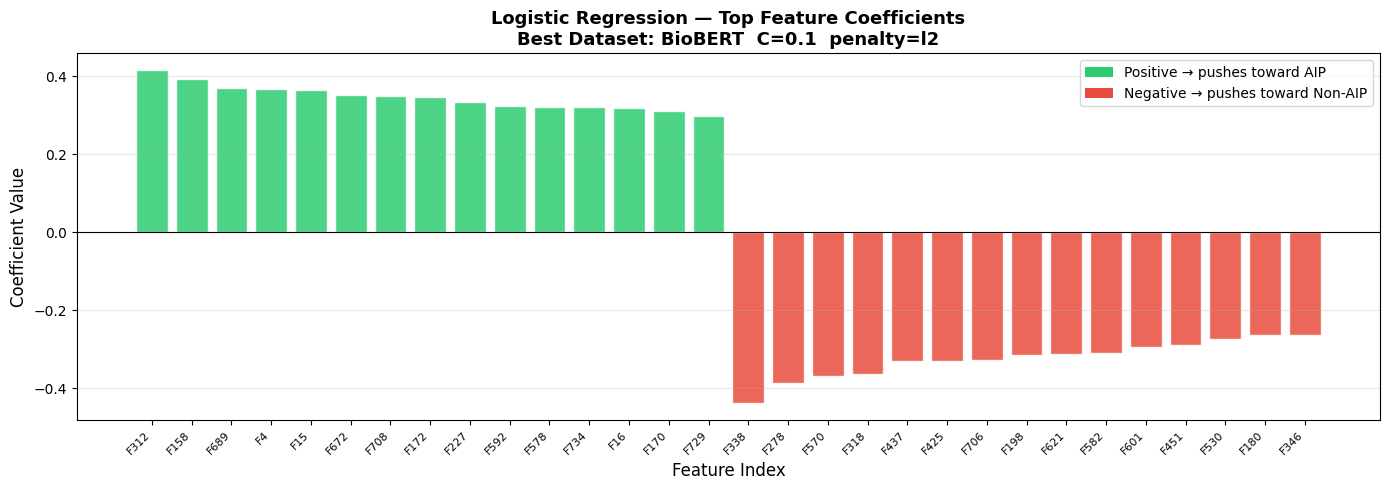

✅ Coefficient plot saved (BioBERT)
  LOGISTIC REGRESSION — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/logistic_regression
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/logistic_regression
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/logistic_regression

─────────────────────────────────────────────────────────────────
  Dataset             C Pen               Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  BioBERT           0.1 l2             0.7093   0.6844   0.7259   0.6534   0.4052   0.7416 ★
  ESM2             0.01 l2             0.6910   0.6312   0.7310   0.6206   0.3602   0.7311
  ESMC             0.01 l2             0.6773   0.6274   0.7107   0.6089   0.3351   0.7260
  ProtT5           0.01 l2             0.6651   0.6046   0.7056   0.5911   0.3080   0.7141
  ProtBERT       

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/logistic_regression"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/logistic_regression"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/logistic_regression"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── Logistic Regression hyperparameters ──────────────────────
#
#  Logistic Regression overview:
#    Linear classifier that models P(y=1|X) using the sigmoid
#    function. Despite its name, it is a classification algorithm.
#    Well-suited for linearly separable features and high-dim
#    embeddings (PLM features) due to its linear decision boundary.
#
#  Key parameters:
#    penalty      : regularisation type
#                   "l2"      — Ridge (default) ✅ most common
#                   "l1"      — Lasso, produces sparse weights
#                               (useful for DPC 400 features)
#                   "elasticnet" — combination of L1+L2
#                   "none"    — no regularisation
#    C            : inverse of regularisation strength
#                   smaller C = stronger regularisation
#                   larger  C = weaker regularisation (overfit risk)
#                   try: 0.001, 0.01, 0.1, 1, 10, 100
#    solver       : optimisation algorithm
#                   "lbfgs"   — default, good for L2 ✅
#                   "liblinear" — good for L1 and small datasets
#                   "saga"    — supports all penalties, good for large data
#    max_iter     : max solver iterations — increase if convergence warning
#    class_weight : "balanced" for 1:1.5 AIP/non-AIP imbalance
#    multi_class  : "auto" = binary for our task
#
LR_PARAMS = {
    "penalty"     : "l2",
    "C"           : 1.0,
    "solver"      : "lbfgs",
    "max_iter"    : 1000,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs"      : -1,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets      : {len(DATASETS)}")
print(f"   Train/Test    : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   penalty       : {LR_PARAMS['penalty']}")
print(f"   C             : {LR_PARAMS['C']}")
print(f"   solver        : {LR_PARAMS['solver']}")
print(f"   class_weight  : {LR_PARAMS['class_weight']}")
print(f"   max_iter      : {LR_PARAMS['max_iter']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — C (Regularisation) Sensitivity Analysis
#            C controls the trade-off between fitting training
#            data and keeping weights small.
#            Tests: 0.001, 0.01, 0.1, 1, 10, 100
# ============================================================

print("=" * 65)
print("  Logistic Regression — C Sensitivity Analysis")
print("=" * 65)

C_VALUES    = [0.001, 0.01, 0.1, 1, 10, 100]
best_C_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    c_aucs = {}
    for c in C_VALUES:
        lr = LogisticRegression(
            penalty      = LR_PARAMS["penalty"],
            C            = c,
            solver       = LR_PARAMS["solver"],
            max_iter     = LR_PARAMS["max_iter"],
            class_weight = LR_PARAMS["class_weight"],
            random_state = LR_PARAMS["random_state"],
            n_jobs       = LR_PARAMS["n_jobs"],
        )
        lr.fit(X_train, y_train)
        y_prob_c = lr.predict_proba(X_test)[:, 1]
        c_aucs[c] = round(roc_auc_score(y_test, y_prob_c), 4)

    best_C              = max(c_aucs, key=c_aucs.get)
    best_C_per_ds[ds_name] = best_C

    c_str = "  ".join([f"C={k}:{v:.3f}" for k, v in c_aucs.items()])
    print(f"\n  {ds_name:<10} → {c_str}")
    print(f"             Best C = {best_C}  (AUC={c_aucs[best_C]:.4f})")

print(f"\n✅ C sensitivity analysis complete")
print(f"   Best C per dataset: {best_C_per_ds}")


# ============================================================
#   CELL 6 — C Sensitivity Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    c_aucs = []
    for c in C_VALUES:
        lr = LogisticRegression(
            penalty=LR_PARAMS["penalty"], C=c,
            solver=LR_PARAMS["solver"],
            max_iter=LR_PARAMS["max_iter"],
            class_weight=LR_PARAMS["class_weight"],
            random_state=LR_PARAMS["random_state"],
            n_jobs=-1,
        )
        lr.fit(X_train, y_train)
        y_prob_c = lr.predict_proba(X_test)[:, 1]
        c_aucs.append(roc_auc_score(y_test, y_prob_c))

    best_C   = best_C_per_ds.get(ds_name, 1.0)
    best_idx = C_VALUES.index(best_C)

    ax.semilogx(C_VALUES, c_aucs, "o-",
                color="#c0392b", linewidth=2, markersize=6)
    ax.scatter([best_C], [c_aucs[best_idx]],
               color="#27ae60", s=100, zorder=5,
               label=f"Best C={best_C}")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("C (log scale)", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Logistic Regression — AUC vs C (Regularisation) per Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LR_C_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ C sensitivity plot saved")


# ============================================================
#   CELL 7 — Penalty Comparison per Dataset
#            Compares L1, L2, ElasticNet using best C
# ============================================================

print("=" * 65)
print("  Logistic Regression — Penalty Comparison per Dataset")
print("=" * 65)

# saga solver supports all penalties
PENALTIES           = ["l1", "l2", "elasticnet"]
best_penalty_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    best_C = best_C_per_ds.get(ds_name, 1.0)

    penalty_aucs = {}
    for penalty in PENALTIES:
        l1_ratio = 0.5 if penalty == "elasticnet" else None
        lr = LogisticRegression(
            penalty      = penalty,
            C            = best_C,
            solver       = "saga",       # saga supports all penalties
            l1_ratio     = l1_ratio,
            max_iter     = LR_PARAMS["max_iter"],
            class_weight = LR_PARAMS["class_weight"],
            random_state = LR_PARAMS["random_state"],
            n_jobs       = -1,
        )
        lr.fit(X_train, y_train)
        y_prob_p          = lr.predict_proba(X_test)[:, 1]
        penalty_aucs[penalty] = round(roc_auc_score(y_test, y_prob_p), 4)

    best_penalty                = max(penalty_aucs, key=penalty_aucs.get)
    best_penalty_per_ds[ds_name] = best_penalty

    p_str = "  ".join([f"{k}:{v:.3f}" for k, v in penalty_aucs.items()])
    print(f"\n  {ds_name:<10} → {p_str}")
    print(f"             Best penalty = {best_penalty}  "
          f"(AUC={penalty_aucs[best_penalty]:.4f})")

print(f"\n✅ Penalty comparison complete")
print(f"   Best penalty per dataset: {best_penalty_per_ds}")


# ============================================================
#   CELL 8 — Main Training Loop
#            Uses best C and best penalty found per dataset
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  Logistic Regression — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    # ⚠️ Critical for LR — coefficients depend on feature scale
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Use best C and penalty from sensitivity analyses ──────
    C_used       = best_C_per_ds.get(ds_name, LR_PARAMS["C"])
    penalty_used = best_penalty_per_ds.get(ds_name, LR_PARAMS["penalty"])

    # saga solver handles all penalties; lbfgs only handles l2/none
    solver_used  = "saga" if penalty_used in ["l1", "elasticnet"] \
                   else LR_PARAMS["solver"]
    l1_ratio     = 0.5 if penalty_used == "elasticnet" else None

    print(f"  C       : {C_used}  |  penalty : {penalty_used}  "
          f"|  solver : {solver_used}")

    # ── Train Logistic Regression ────────────────────────────
    clf = LogisticRegression(
        penalty      = penalty_used,
        C            = C_used,
        solver       = solver_used,
        l1_ratio     = l1_ratio,
        max_iter     = LR_PARAMS["max_iter"],
        class_weight = LR_PARAMS["class_weight"],
        random_state = LR_PARAMS["random_state"],
        n_jobs       = LR_PARAMS["n_jobs"],
    )
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]      = ds_name
    metrics["Features"]     = X.shape[1]
    metrics["C_used"]       = C_used
    metrics["Penalty_used"] = penalty_used
    metrics["Train_N"]      = len(X_train)
    metrics["Test_N"]       = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR,
                             f"{ds_name}_LR_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test" : y_test,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "clf"    : clf,
        "scaler" : scaler,
        "C"      : C_used,
        "penalty": penalty_used,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 9 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "C_used", "Penalty_used", "Accuracy",
               "Sensitivity", "Specificity", "F1_Score",
               "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── Logistic Regression Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "LR_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 10 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR,
                                f"LR_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR,
                                f"LR_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset : {best_name}")
print(f"   C       : {best_C_per_ds.get(best_name)}")
print(f"   Penalty : {best_penalty_per_ds.get(best_name)}")
print(f"   AUC     : {best_auc:.4f}")
print(f"   Model   : {best_model_path}")
print(f"   Scaler  : {best_scaler_path}")


# ============================================================
#   CELL 11 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity",
             "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("Logistic Regression — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15,
                   ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LR_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 12 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Logistic Regression — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"],
                   rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LR_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 13 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} [{data['penalty']}] (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Logistic Regression — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LR_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 14 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"C={best_C_per_ds.get(best_name)}  "
             f"penalty={best_penalty_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"LR_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 15 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, pen in zip(bars, sorted_df["AUC"],
                          sorted_df["Penalty_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  ({pen})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("Logistic Regression — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "LR_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 16 — Visualization 6: Top Feature Coefficients
#             LR provides signed coefficients — unique vs tree
#             models. Positive coeff → pushes toward AIP (1).
#             Negative coeff → pushes toward non-AIP (0).
# ============================================================

coef = best_model.coef_[0]       # shape: (n_features,)
n_top = min(30, len(coef))

# Top 15 positive and top 15 negative coefficients
top_pos_idx = np.argsort(coef)[::-1][:n_top // 2]
top_neg_idx = np.argsort(coef)[:n_top // 2]
top_idx     = np.concatenate([top_pos_idx, top_neg_idx])
top_coef    = coef[top_idx]
top_labels  = [f"F{i}" for i in top_idx]
coef_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in top_coef]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top_coef)), top_coef,
       color=coef_colors, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(top_coef)))
ax.set_xticklabels(top_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Coefficient Value", fontsize=12)
ax.set_title(f"Logistic Regression — Top Feature Coefficients\n"
             f"Best Dataset: {best_name}  "
             f"C={best_C_per_ds.get(best_name)}  "
             f"penalty={best_penalty_per_ds.get(best_name)}",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Positive → pushes toward AIP"),
    Patch(facecolor="#e74c3c", label="Negative → pushes toward Non-AIP"),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"LR_coefficients_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Coefficient plot saved ({best_name})")


# ============================================================
#   CELL 17 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  LOGISTIC REGRESSION — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'C':>8} {'Pen':<12} {'Acc':>8} {'Sn':>8} "
      f"{'Sp':>8} {'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {row['C_used']:>8} "
          f"{row['Penalty_used']:<12} "
          f"{row['Accuracy']:>8.4f} {row['Sensitivity']:>8.4f} "
          f"{row['Specificity']:>8.4f} {row['F1_Score']:>8.4f} "
          f"{row['MCC']:>8.4f} {row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset  : {best_name}")
print(f"     C             : {best_C_per_ds.get(best_name)}")
print(f"     Penalty       : {best_penalty_per_ds.get(best_name)}")
print(f"     Accuracy      : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity   : {best_row['Sensitivity']:.4f}")
print(f"     Specificity   : {best_row['Specificity']:.4f}")
print(f"     F1 Score      : {best_row['F1_Score']:.4f}")
print(f"     MCC           : {best_row['MCC']:.4f}")
print(f"     AUC           : {best_row['AUC']:.4f}")
print(f"\n  Logistic Regression advantages:")
print(f"     ✅ Interpretable signed coefficients per feature")
print(f"     ✅ Fastest training of all classifiers")
print(f"     ✅ Strong baseline for PLM high-dim embeddings (linear)")
print(f"     ✅ Best C selected per dataset automatically")
print(f"     ✅ Best penalty (L1/L2/ElasticNet) selected per dataset")
print(f"     ✅ class_weight='balanced' handles 1:1.5 imbalance")
print("=" * 65)